In [1]:
import os
os.getcwd()

'/home/yyu27/D-PACKAGE'

In [2]:
# import anndata
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.distributions import MultivariateNormal

import os
# os.environ["CUDA_VISIBLE_DEVICES"]="4"

import copy

import tqdm

from typing import List, Union

In [3]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
from codes.utils.util import *
from codes.drugcell_NN import *

In [5]:
from codes.utils.util import *
from codes.drugcell_NN import *

if torch.cuda.is_available():
  DEVICE = 'cuda'
else:
  DEVICE = 'cpu'
  
torch.cuda.device_count()

1

In [6]:
torch.cuda.device_count()

1

In [7]:
!nvidia-smi

Tue Oct 14 14:46:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:81:00.0 Off |                   On |
| N/A   30C    P0             73W /  500W |     309MiB /  81920MiB |     N/A      Default |
|                                         |                        |            Disabled* |
+-----------------------------------------+-----

In [8]:
if torch.cuda.is_available():
      DEVICE = 'cuda'
else:
  DEVICE = 'cpu'

In [9]:
retrain = False

# Data Loading

## GTEX


In [10]:
class RNASeqData(Dataset):
    
    def __init__(self, X, c=None, y=None, transform=None):
        self.X = X
        self.y = y
        self.c = c
        self.transform = transform
        
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, index):
        sample = self.X[index,:]
        
        if self.transform is not None:
            sample = self.transform(sample)
        
        if self.y is not None and self.c is None:
            return sample, self.y[index]
        elif self.y is not None and self.c is not None:
            return sample, self.y[index], self.c[index]
        elif self.y is None and self.c is not None:
            return sample, self.c[index]
        else:
            return sample

In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

expr_df = pd.read_csv("data/train_gtex_expression_matrix_processed.tsv.gz", sep="\t", index_col=0)


attrs_df = pd.read_csv(
    "data/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt",
    sep="\t",
    usecols=["SAMPID", "SMTSD", "SMTS"]
)
attrs_df = attrs_df.set_index('SAMPID')
attrs_sub = attrs_df.loc[expr_df.index]

In [13]:
le = LabelEncoder()
tissue_labels = le.fit_transform(attrs_sub['SMTSD'])

code_to_name = {code: f"{i}" for i, code in enumerate(le.classes_)}

gtex_sample_identifiers = pd.DataFrame({
    'sample_id': expr_df.index,
    'tissue_type': attrs_sub['SMTSD'].map(code_to_name)
}).set_index('sample_id')

print(gtex_sample_identifiers.head())


                         tissue_type
sample_id                           
GTEX-T5JC-1526-SM-4DM68           33
GTEX-XMK1-0326-SM-4B652           40
GTEX-11NSD-2026-SM-5HL5U          37
GTEX-12WSA-1426-SM-5EGJU          28
GTEX-ZDTT-2626-SM-5S2OP            0


In [14]:
## expression and IHC data

rna_seq = pd.read_csv('data/train_gtex_expression_matrix_processed.tsv.gz',sep='\t',index_col=0)
# abeta_data = pd.read_csv('data/alzheimers-disease-gene-modules-master-data-preprocessed_data/data/preprocessed_data/All_Datasets_Abeta_IHC_Labels.tsv',index_col=0,sep='\t')

In [15]:
gtex_mad_genes = pd.read_csv('data/gtex_mad_genes.tsv', sep='\t')
gtex_sample_counts = pd.read_csv('data/gtex_sample_counts.tsv', sep='\t')

In [16]:
# rna_seq = rna_seq.loc[:,tcga_mad_genes.gene_id[:3000].apply(str)]
rna_seq = rna_seq / rna_seq.std()
rna_seq = np.log(rna_seq + 1)

In [17]:
rna_seq.shape

(10519, 18356)

In [18]:
gtex_sample_identifiers

,tissue_type
sample_id,
GTEX-T5JC-1526-SM-4DM68,33
GTEX-XMK1-0326-SM-4B652,40
GTEX-11NSD-2026-SM-5HL5U,37
GTEX-12WSA-1426-SM-5EGJU,28
GTEX-ZDTT-2626-SM-5S2OP,0
...,...
GTEX-13PVQ-0126-SM-5SIB4,44
GTEX-XXEK-1226-SM-4BRUY,42
GTEX-15SHU-1026-SM-6PAL7,4


In [ ]:
# meta data labels 
# dataset_labels = pd.read_csv('data/alzheimers-disease-gene-modules-master-data-preprocessed_data/data/preprocessed_data/All_Dataset_Labels.tsv',index_col=0,sep='\t')
# region_labels = pd.read_csv('data/alzheimers-disease-gene-modules-master-data-preprocessed_data/data/preprocessed_data/All_Joined_Region_Labels.tsv',index_col=0,sep='\t')

### Transfer the entrezgene_id to hgnc_symbol

In [19]:
gtex_df = rna_seq

In [22]:
gtex_df = pd.read_csv("data/gtex_df_filtered.csv", index_col=0)

# DCell

In [26]:
training_file = "data/drugcell_train.txt"
testing_file = "data/drugcell_test.txt"
val_file = "data/drugcell_val.txt"
cell2id_file = "data/cell2ind.txt"
drug2id_file = "data/drug2ind.txt"
genotype_file = "data/cell2mutation.txt"
fingerprint_file = "data/drug2fingerprint.txt"
onto_file = "data/drugcell_ont.txt"
gene2id_file = "data/gene2ind.txt"

train_data, feature_dict, cell2id_mapping, drug2id_mapping = prepare_train_data(training_file, 
                                                                  testing_file, cell2id_file, 
                                                                  drug2id_file)

gene2id_mapping = load_mapping(gene2id_file)

# load cell/drug features
cell_features = np.genfromtxt(genotype_file, delimiter=',')
drug_features = np.genfromtxt(fingerprint_file, delimiter=',')

num_cells = len(cell2id_mapping)
num_drugs = len(drug2id_mapping)
num_genes = len(gene2id_mapping)
drug_dim = len(drug_features[0,:])

# load ontology
dG, root, term_size_map, \
    term_direct_gene_map = load_ontology(onto_file, 
                                         gene2id_mapping)

Total number of cell lines = 1225
Total number of drugs = 684
There are 3008 genes
There are 1 roots: GO:0008150
There are 2086 terms
There are 1 connected componenets


In [29]:
train_feature, train_label, test_feature, test_label = train_data

In [30]:
train_loader = du.DataLoader(du.TensorDataset(train_feature,train_label),
                                 batch_size=32, shuffle=False)

In [31]:
for i, (inputdata, labels) in enumerate(train_loader):
    features = build_input_vector(inputdata, cell_features, drug_features)
    break

In [32]:
cell_features.shape

(1225, 3008)

In [33]:
features.shape

torch.Size([32, 5056])

### Load drug file

In [34]:
cell_features = np.genfromtxt("data/cell2mutation.txt", delimiter=',') 

In [35]:
fingerprint='data/drug2fingerprint.txt'
drug_features = np.genfromtxt(fingerprint, delimiter=',')


In [36]:
cell2id='data/cell2ind.txt'

cell2id_mapping = load_mapping(cell2id)

In [37]:
def load_train_data(file_name, cell2id, drug2id):
    feature = []
    label = []
    feature_dict = {}
    with open(file_name, 'r') as fi:
        for line in fi:
            tokens = line.strip().split('\t')
            keys = list(cell2id.keys())[list(cell2id.values()).index(cell2id[tokens[0]])] + ";" + list(drug2id.keys())[list(drug2id.values()).index(drug2id[tokens[1]])]
            feature.append([cell2id[tokens[0]], drug2id[tokens[1]]])
            feature_dict[keys] = [cell2id[tokens[0]], drug2id[tokens[1]]]
            label.append([float(tokens[2])])
    return feature, label, feature_dict

In [38]:
feature, label, feature_dict = load_train_data("data/drugcell_train.txt", cell2id_mapping, drug2id_mapping)

In [39]:
tissue_type = gtex_sample_identifiers.loc[gtex_df.index, 'tissue_type']
tissue_type.value_counts()

tissue_type
37    508
44    426
49    401
0     398
5     397
35    384
38    373
28    366
52    366
43    348
29    333
1     319
21    309
32    273
3     269
31    267
20    261
26    247
47    236
48    233
40    223
27    220
25    210
2     171
41    165
34    157
11    156
4     156
46    146
9     144
12    142
42    137
16    132
45    123
10    122
39    120
22    117
13    116
17    112
14    111
8     109
15    109
51    103
50    100
7      90
36     87
18     82
19     79
33     40
6      10
30      6
24      5
23      5
Name: count, dtype: int64

In [40]:
inputdata

tensor([[ 208.,  139.],
        [  87.,  194.],
        [  27.,  608.],
        [ 957.,  307.],
        [ 920.,  137.],
        [ 171.,  578.],
        [ 324.,  403.],
        [ 981.,  171.],
        [ 634.,   72.],
        [ 261.,  331.],
        [ 268.,    2.],
        [ 878.,  216.],
        [ 492.,  660.],
        [ 354.,  396.],
        [ 394.,  177.],
        [ 947.,  554.],
        [ 123.,  216.],
        [ 794.,  474.],
        [ 423.,  572.],
        [ 201.,  290.],
        [1137.,  522.],
        [ 962.,  146.],
        [ 125.,   69.],
        [ 109.,  171.],
        [ 813.,  365.],
        [1090.,   91.],
        [ 900.,  568.],
        [ 784.,  201.],
        [1065.,   62.],
        [ 223.,  624.],
        [ 142.,  667.],
        [ 520.,  674.]])

In [41]:
len(list(set(gene2id_mapping.keys()) & set(gtex_df.columns)))

2698

In [42]:
len(gene2id_mapping.keys())

3008

### Create gene2ID for gtex

In [43]:
gtex_gene2id = {}
for idx, gene in enumerate(gtex_df.columns):
    gtex_gene2id[gene] = idx

### Align gene id with gtex


In [44]:
gene_intersect_list = list(set(gene2id_mapping.keys()) & set(gtex_df.columns))
gtex_tensor = torch.zeros(gtex_df.shape[0], num_genes)

In [45]:
for gene in tqdm.tqdm(gene_intersect_list):
    idx = gene2id_mapping[gene]
    gtex_tensor[:,idx] = torch.tensor(gtex_df[gene])

  0%|          | 0/2698 [00:00<?, ?it/s]

100%|██████████| 2698/2698 [00:46<00:00, 58.48it/s]


(array([3.370e+02, 1.148e+03, 3.751e+03, 3.326e+03, 1.220e+03, 4.100e+02,
        2.110e+02, 9.600e+01, 1.700e+01, 3.000e+00]),
 array([0.01915766, 0.28537628, 0.55159485, 0.81781352, 1.08403206,
        1.35025072, 1.61646938, 1.88268793, 2.14890647, 2.41512513,
        2.68134379]),
 <BarContainer object of 10 artists>)

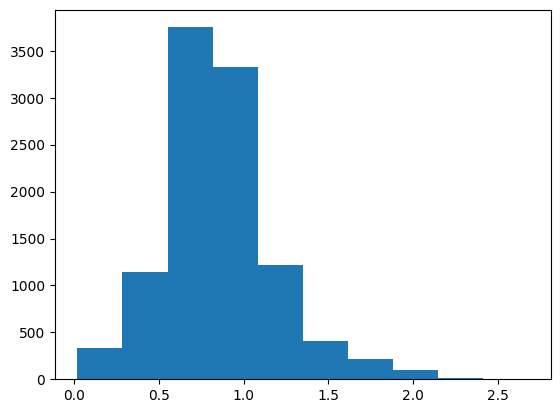

In [46]:
plt.hist(gtex_tensor[:,4])

In [47]:
tissue_type = tissue_type.astype(int)
tissue_type_filtered = tissue_type[tissue_type >= 500]

In [48]:
tissue_2_idx = {}
idx_2_tissue = {}
tissue_type_idx = []

i = 0
for tissue in tissue_type:
    if tissue not in tissue_2_idx:
        tissue_2_idx[tissue] = i
        idx_2_tissue[i] = tissue
        tissue_type_idx.append(i)
        
        i += 1
    else:
        tissue_type_idx.append(tissue_2_idx[tissue])

In [49]:
y = torch.tensor(tissue_type_idx)

In [50]:
torch.manual_seed(0)
gtex_dataset = RNASeqData(X = gtex_tensor, y = y)


In [51]:
X = gtex_dataset.X  # torch.Tensor
y = gtex_dataset.y  # torch.Tensor

mean = X.mean(0)
std = X.std(0)

X = (X - mean) / (std + 1e-6)

y_np = y.numpy()

y_counts = pd.Series(y_np).value_counts()

valid_labels = y_counts[y_counts > 200].index.values

valid_mask = torch.isin(y, torch.tensor(valid_labels))

X_filtered = X[valid_mask]
y_filtered = y[valid_mask]

unique_labels = torch.unique(y_filtered)
label_mapping = {old.item(): new for new, old in enumerate(unique_labels)}

y_reindexed = torch.tensor([label_mapping[label.item()] for label in y_filtered])

filtered_gtex_dataset = RNASeqData(X=X_filtered, y=y_reindexed)

gtex_dataset = RNASeqData(X=X, y=y)

training_set, testing_set = random_split(filtered_gtex_dataset, [0.9, 0.1])

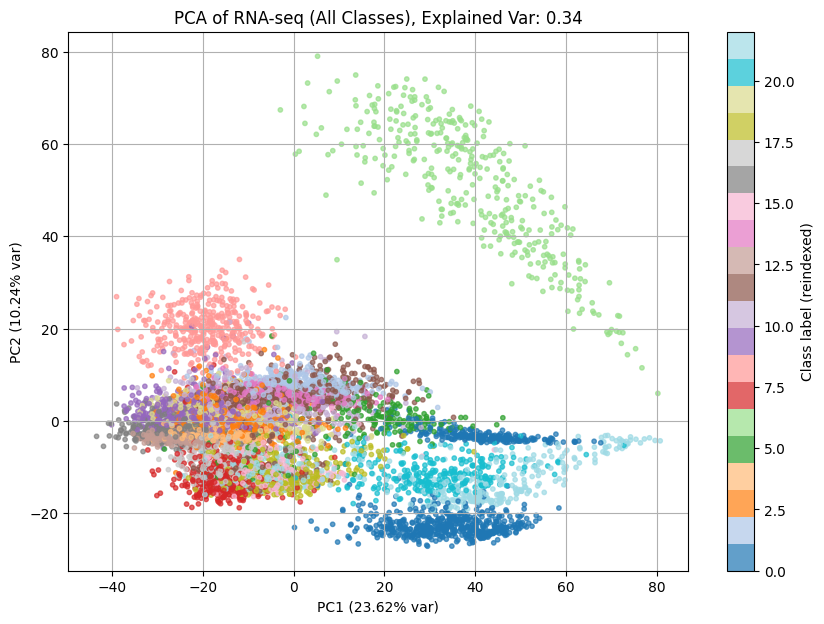

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_np = X_filtered.numpy()
y_np = y_reindexed.numpy()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_np, cmap='tab20', s=10, alpha=0.7)

plt.title(f"PCA of RNA-seq (All Classes), Explained Var: {pca.explained_variance_ratio_[:2].sum():.2f}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} var)")
plt.colorbar(scatter, label='Class label (reindexed)')
plt.grid(True)
plt.show()


In [53]:
train_idx = training_set.indices
val_idx = testing_set.indices

In [54]:
tissue_2_idx

{33: 0,
 40: 1,
 37: 2,
 28: 3,
 0: 4,
 2: 5,
 48: 6,
 22: 7,
 47: 8,
 52: 9,
 5: 10,
 35: 11,
 10: 12,
 15: 13,
 49: 14,
 1: 15,
 46: 16,
 12: 17,
 26: 18,
 44: 19,
 21: 20,
 43: 21,
 25: 22,
 38: 23,
 8: 24,
 41: 25,
 18: 26,
 42: 27,
 4: 28,
 3: 29,
 29: 30,
 7: 31,
 39: 32,
 13: 33,
 50: 34,
 14: 35,
 20: 36,
 11: 37,
 31: 38,
 17: 39,
 19: 40,
 27: 41,
 9: 42,
 51: 43,
 34: 44,
 16: 45,
 45: 46,
 32: 47,
 36: 48,
 6: 49,
 24: 50,
 23: 51,
 30: 52}

In [ ]:
train_labels = torch.tensor([training_set[i][1] for i in range(len(training_set))])
test_labels = torch.tensor([testing_set[i][1] for i in range(len(testing_set))])